# Explicabilidade Adaptativa com LIME e SLMs: Um Estudo no Dataset Breast Cancer

Este notebook implementa um experimento de Interpretabilidade de IA inspirado na metodologia de "[_Enhancing the Interpretability of SHAP Values Using Large Language Models_](https://arxiv.org/abs/2409.00079#)". O objetivo central é investigar como otimizar a fidelidade das explicações do modelo Naive Bayes utilizando o LIME (Local Interpretable Model-agnostic Explanations) em conjunto com modelos de linguagem de pequeno porte (SLMs).

#### O Problema: O Equilíbrio das Perturbações
No LIME a qualidade da explicação local depende drasticamente do número de amostras perturbadas geradas em torno de uma instância.

- Poucas perturbações: podem gerar explicações instáveis ou ruidosas.
- Muitas perturbações: aumentam o custo computacional desnecessariamente.

Neste projeto, avaliamos como escolher de maneira adaptativa o número de perturbações necessárias para cada consulta. O critério de sucesso é a produção de uma explicação coerente e fiel, que será posteriormente processada por uma SLM (Qwen 2.5) para traduzir coeficientes estatísticos em uma narrativa clínica compreensível.

## 1 - Importando dependências

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from lime.lime_tabular import LimeTabularExplainer
from src.loader import DataLoader
from src.model import train_naive_bayes, evaluate_model
from src.lime_utils import show_html, explanation_to_dict, explanation_similarity
from src.slm_utils import query_slm
from src.prompts import get_oncology_specialist_prompt, get_data_analyst_prompt, get_feature_explainer_prompt

## 2 - Análise Exploratória de Dados

Para este experimento, utilizamos o conjunto de dados Breast Cancer (disponível na biblioteca sklearn), que contém registros de 569 amostras de células extraídas de massas mamárias. O desafio é classificar se um tumor é Malignos (1) e Benignos (0) a partir de características visuais dos núcleos celulares.

A análise baseia-se em 10 métricas fundamentais da morfologia celular:

- Dimensões: Raio, Perímetro e Área.
- Forma: Suavidade, Compacidade, Concavidade e Pontos Côncavos.
- Textura e Simetria: Desvio padrão de cinza, Simetria e Dimensão Fractal.

Cada uma dessas métricas foi calculada de três formas: Média (Mean), Erro Padrão (SE) e o Pior Caso (Worst), que representa a média dos três maiores valores medidos. Essa combinação resulta em um total de 30 variáveis preditivas.

### 2.1 - Carregando os dados

In [3]:
data_loader = DataLoader()
df = data_loader.load_sklearn_dataset()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2.2 - Entendo os Dados

In [4]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 2.4 - Visualização dos dados

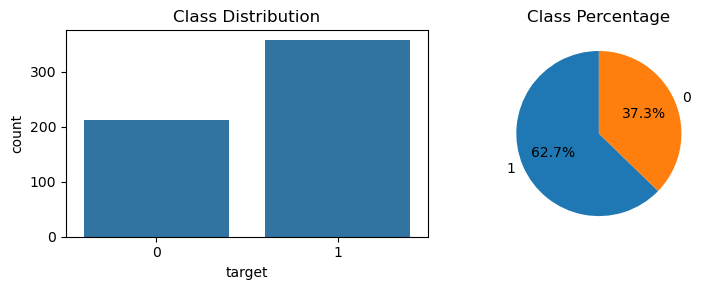

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8,3))

# Countplot
sns.countplot(x="target", data=df, ax=axes[0])
axes[0].set_title("Class Distribution")

# Pizza
counts = df["target"].value_counts()
axes[1].pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Class Percentage")

plt.tight_layout()
plt.show()

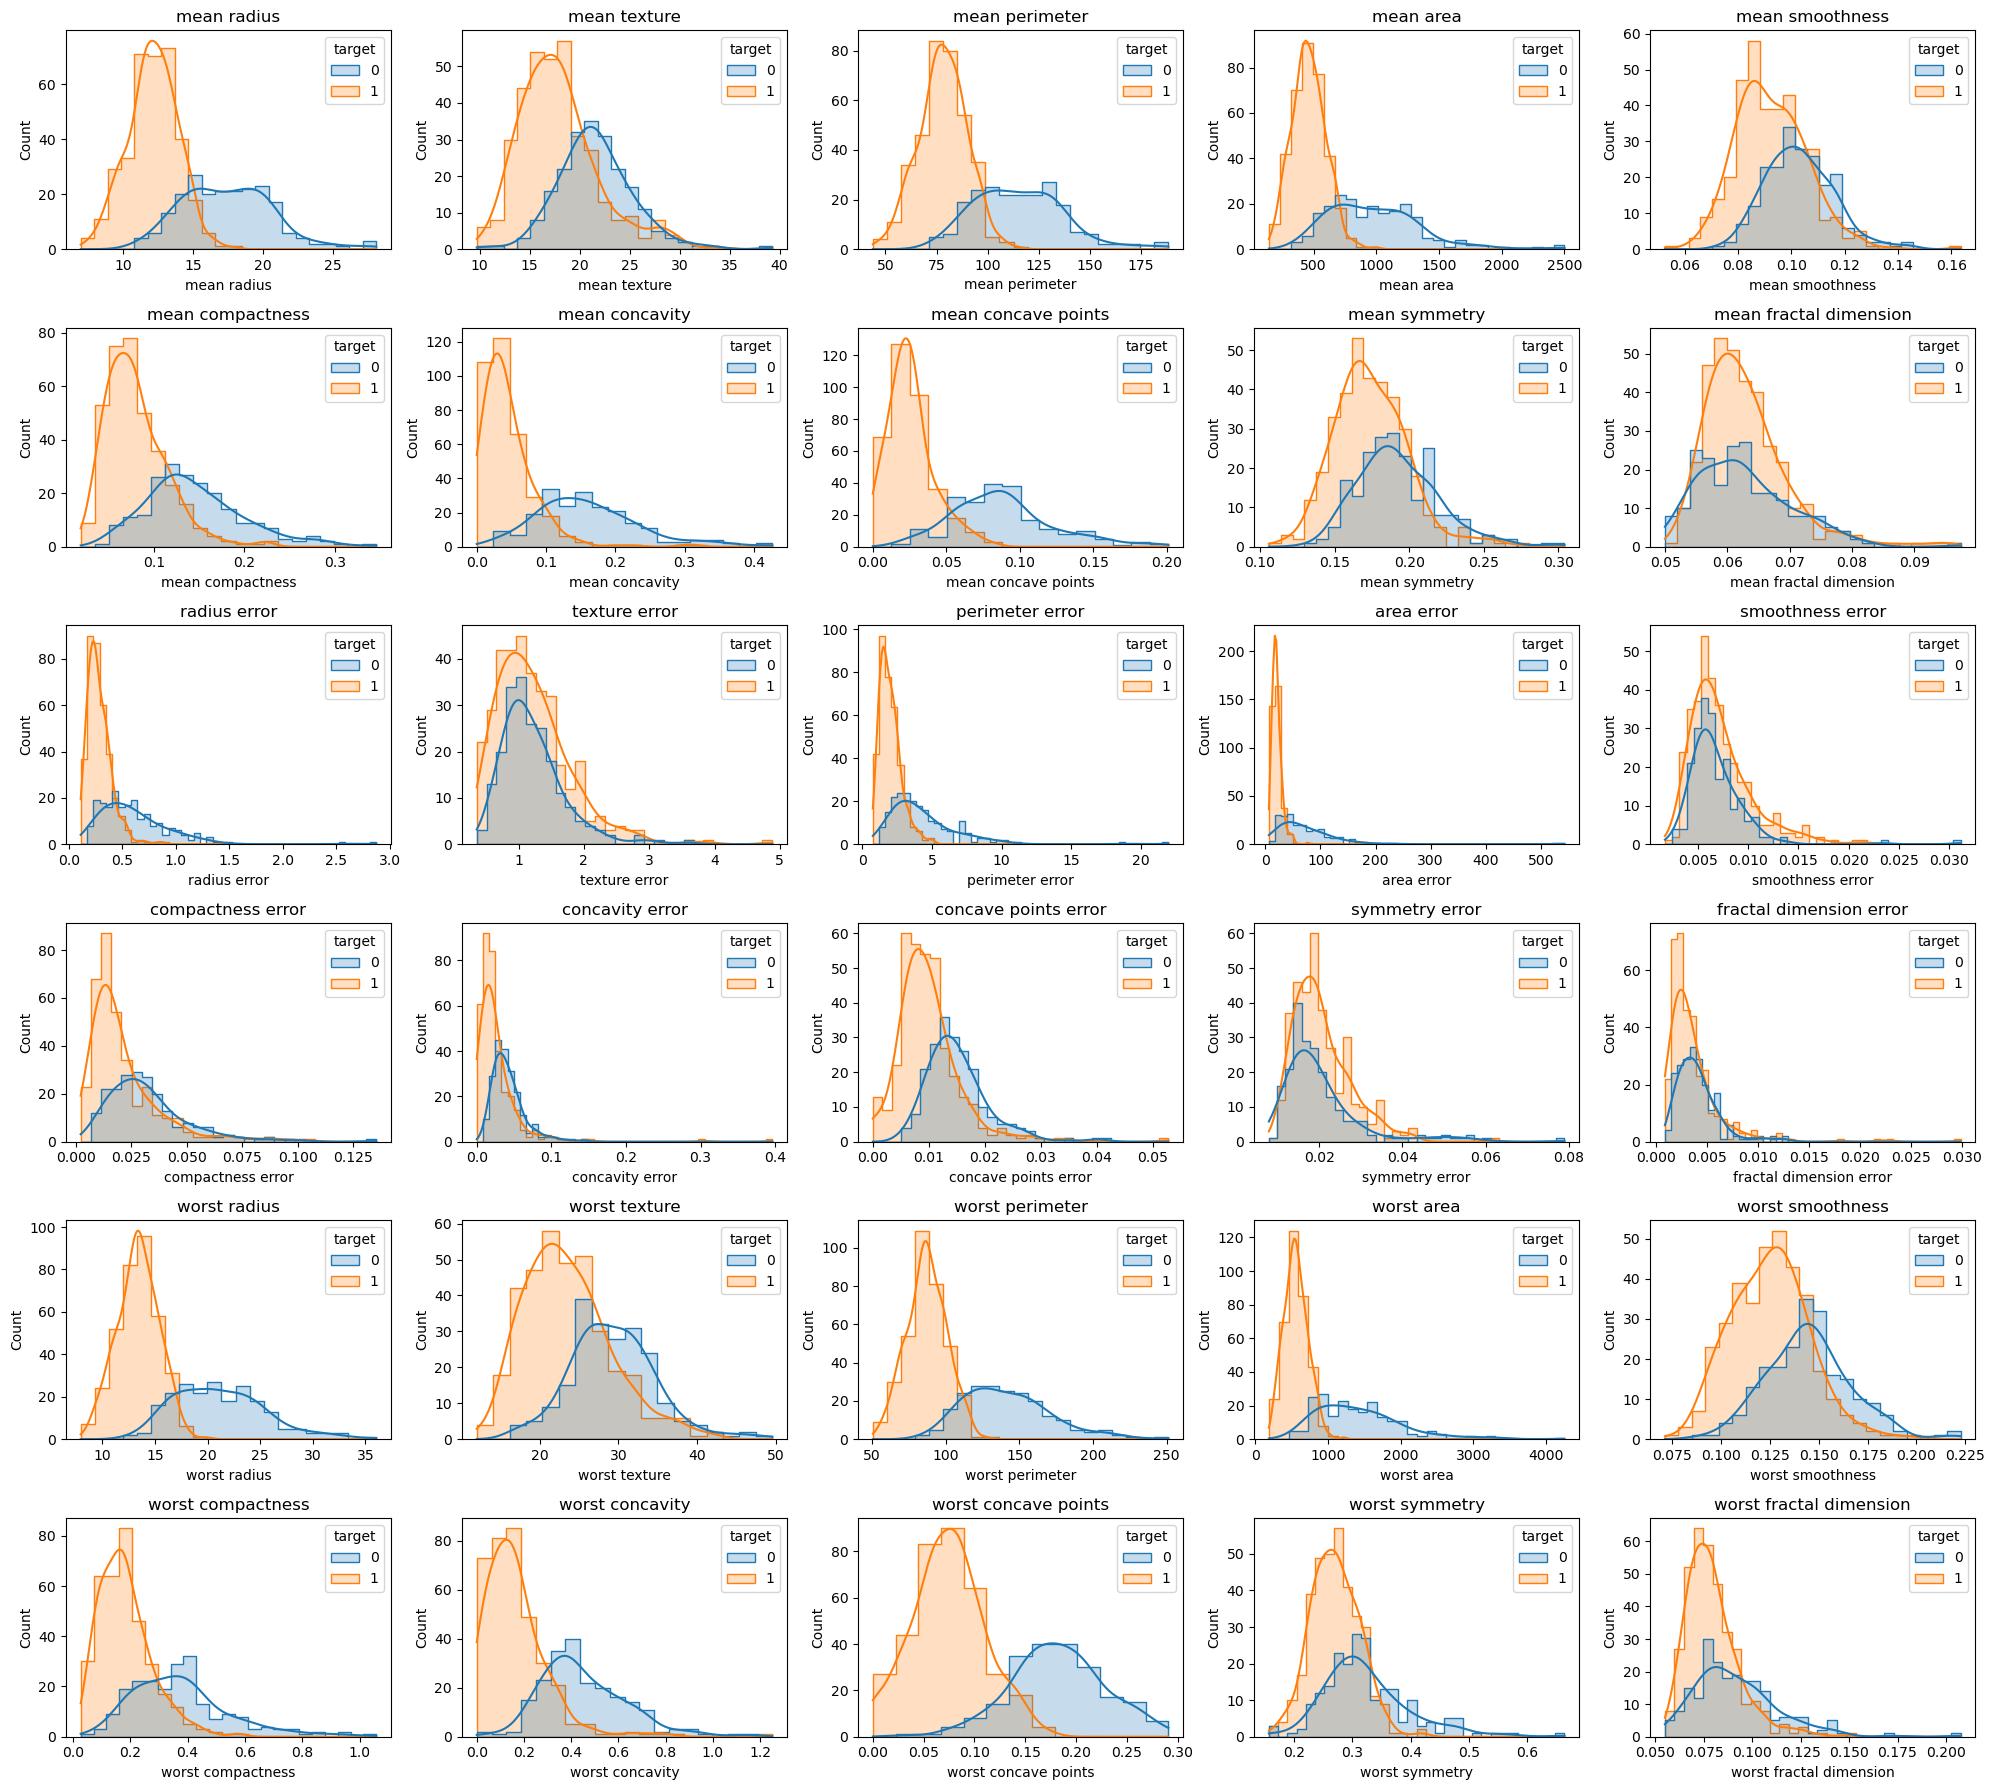

In [8]:
features = df.drop("target", axis=1).columns

plt.figure(figsize=(20,18))

for i, col in enumerate(features):
    plt.subplot(6,5,i+1)
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        kde=True,
        element="step"
    )
    plt.title(col)

plt.tight_layout()
plt.show()

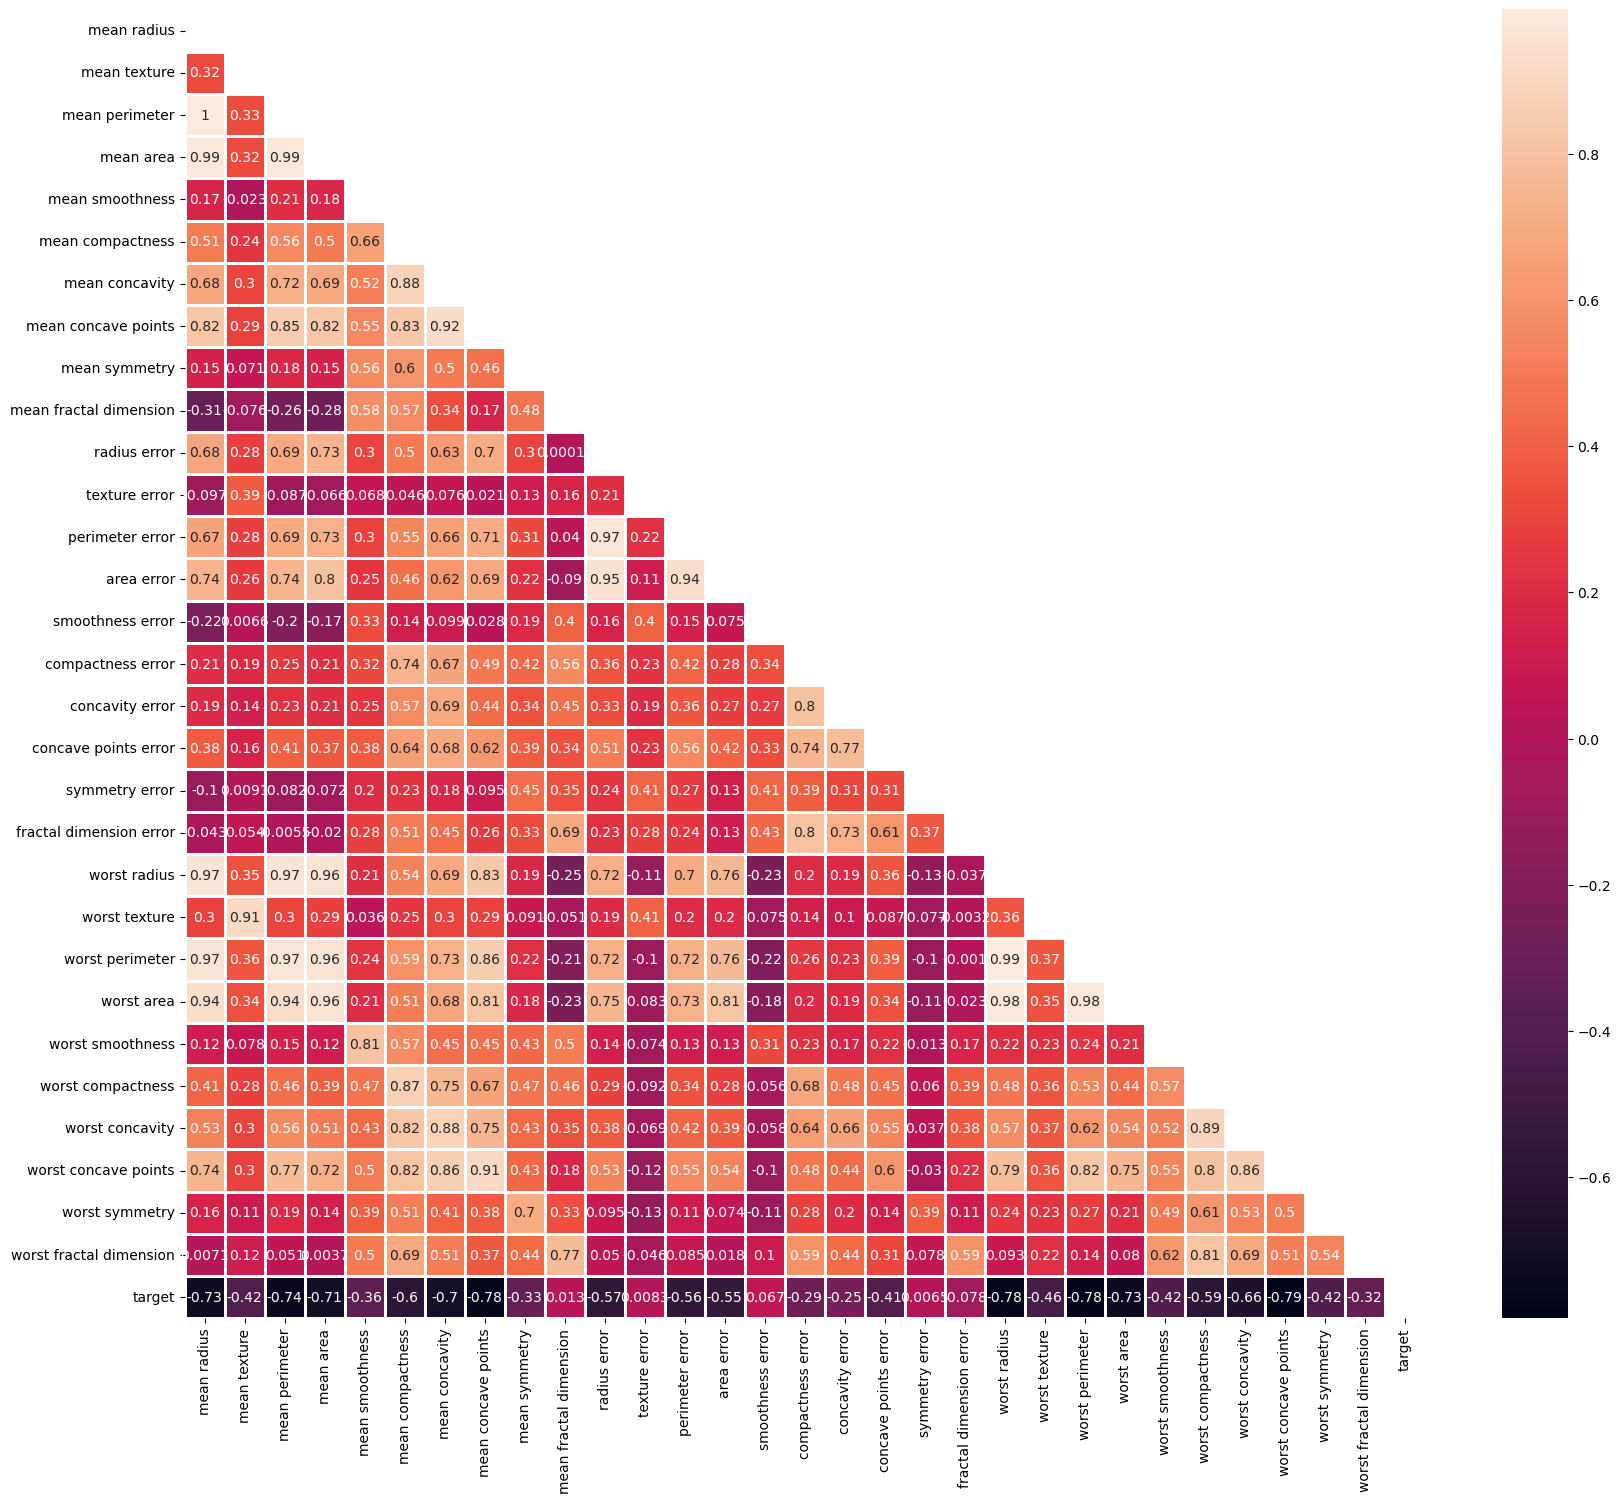

In [9]:
plt.figure(figsize=(20, 17))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, mask=matrix, linewidth=.8, cmap="rocket");

## 3 Pré-processamento

Ao analisar a matriz de correlação, percebemos que várias colunas dizem exatamente a mesma coisa. Para deixar nosso modelo mais leve e preciso, aplicamos três filtros lógicos:

1) Dimensão: Raio, Perímetro e Área são matematicamente dependentes ($Area = \pi r^2$). Manteremos apenas o Raio como a unidade fundamental de tamanho.
2) Média vs. Pior Caso: As colunas "Worst" (piores casos) são altamente correlacionadas com as colunas de "Média". Optamos por focar apenas na Média para entender a tendência geral das células.
3) Forma: as métricas de Concavidade e Pontos Côncavos descrevem quase o mesmo que a Compacidade (Compactness). Ficaremos apenas com a última para simplificar a descrição da forma.

In [10]:
cols_worst = [
    'worst radius', 'worst texture', 'worst perimeter', 'worst area',
    'worst smoothness', 'worst compactness', 'worst concavity',
    'worst concave points', 'worst symmetry', 'worst fractal dimension'
]
df = df.drop(cols_worst, axis=1)

cols_geo = [
    'mean perimeter', 'perimeter error', 
    'mean area', 'area error'
]
df = df.drop(cols_geo, axis=1)

cols_concavity = [
    'mean concavity', 'concavity error', 
    'mean concave points', 'concave points error'
]
df = df.drop(cols_concavity, axis=1)

df.columns

Index(['mean radius', 'mean texture', 'mean smoothness', 'mean compactness',
       'mean symmetry', 'mean fractal dimension', 'radius error',
       'texture error', 'smoothness error', 'compactness error',
       'symmetry error', 'fractal dimension error', 'target'],
      dtype='object')

In [11]:
# Salvando o dataset pré-processado 
df.to_csv("../data/processed/breast_cancer_processed.csv", index=False)

In [12]:
# Dividindo os dados em 80% train e 20% test
X_train, X_test, y_train, y_test = data_loader.split(df, 'target', test_size=0.2, random_state=42)

In [13]:
X_train.sample(5)

,mean radius,mean texture,mean smoothness,mean compactness,mean symmetry,mean fractal dimension,radius error,texture error,smoothness error,compactness error,symmetry error,fractal dimension error
327,12.030,17.93,0.07683,0.03892,0.1382,0.06070,0.2335,0.9097,0.004729,0.006887,0.01466,0.001755
1,20.570,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.013080,0.01389,0.003532
270,14.290,16.82,0.06429,0.02675,0.1508,0.05376,0.1302,0.7198,0.003492,0.003710,0.01536,0.001381
8,13.000,21.82,0.12730,0.19320,0.2350,0.07389,0.3063,1.0020,0.005731,0.035020,0.02143,0.003749
206,9.876,17.27,0.10890,0.07232,0.1934,0.06285,0.2137,1.3420,0.009719,0.012490,0.02210,0.002472


## 4 - Treinando o modelo

In [14]:
gnb = train_naive_bayes(X_train, y_train)

Acurácia: 0.921
F1: 0.920


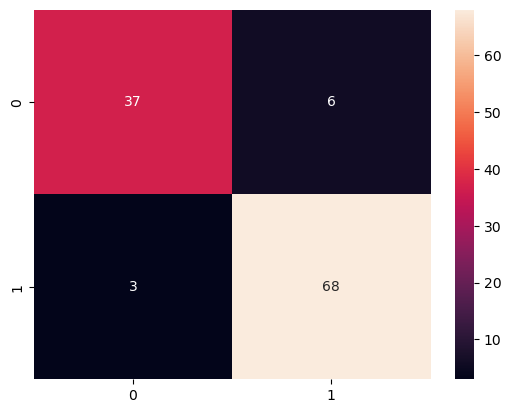

In [15]:
evaluate_model(gnb, X_test, y_test)

## 5 - Lime

Nesta etapa, nosso objetivo é explorar o uso de modelos de linguagem pequenos (SLMs), como o Qwen 2.5 ou o IBM Granite 4.0 Nano, rodando localmente via Docker Model Runner.

O foco do experimento é a eficiência na explicabilidade: em vez de usar um número fixo de amostras para o LIME (que pode ser custoso ou insuficiente), vamos investigar como escolher, de forma adaptativa, a quantidade ideal de perturbações para cada nova pergunta. Queremos garantir que a explicação em texto seja coerente e fiel ao modelo, sem desperdiçar recursos computacionais.

In [16]:
# Gerando um objeto explainer para as classes Malignos (1) e Benignos (0) 
explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=['0', '1'],
    mode='classification',
    random_state=101
)

### 5.1 - Experimentos

In [17]:
import warnings
warnings.filterwarnings("ignore")
import json

def save_dict_to_json(data: dict, filepath: str, indent: int = 4):    
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=indent, ensure_ascii=False)

In [18]:
results = {}
instance = X_test.iloc[20].values

for num_samples in range(5, 10006, 100):
    exp = explainer.explain_instance(
        instance,
        gnb.predict_proba,
        num_samples=num_samples
    )
    results[num_samples] = explanation_to_dict(exp)

In [19]:
save_dict_to_json(results, f"../outputs/results_instance_20.json")

In [20]:
stability = []
prev = None
stability_threshold=0.05

for num_samples in range(5, 10006, 100):
    current = results[num_samples]
    if prev is not None:
        sim = explanation_similarity(prev['feature_importance_map'], current['feature_importance_map'])
        if sim < stability_threshold:
            stability.append((num_samples, sim))
            print(f"Explanation stabilized - samples={num_samples} | sim={sim:.4f}")
    prev = current

Explanation stabilized - samples=505 | sim=0.0422
Explanation stabilized - samples=605 | sim=0.0464
Explanation stabilized - samples=905 | sim=0.0410
Explanation stabilized - samples=1305 | sim=0.0295
Explanation stabilized - samples=1805 | sim=0.0254
Explanation stabilized - samples=1905 | sim=0.0353
Explanation stabilized - samples=2005 | sim=0.0239
Explanation stabilized - samples=2205 | sim=0.0221
Explanation stabilized - samples=2305 | sim=0.0258
Explanation stabilized - samples=2405 | sim=0.0244
Explanation stabilized - samples=2505 | sim=0.0244
Explanation stabilized - samples=2605 | sim=0.0227
Explanation stabilized - samples=2705 | sim=0.0184
Explanation stabilized - samples=3005 | sim=0.0190
Explanation stabilized - samples=3205 | sim=0.0189
Explanation stabilized - samples=3405 | sim=0.0172
Explanation stabilized - samples=3505 | sim=0.0210
Explanation stabilized - samples=3705 | sim=0.0205
Explanation stabilized - samples=3905 | sim=0.0066
Explanation stabilized - samples=4

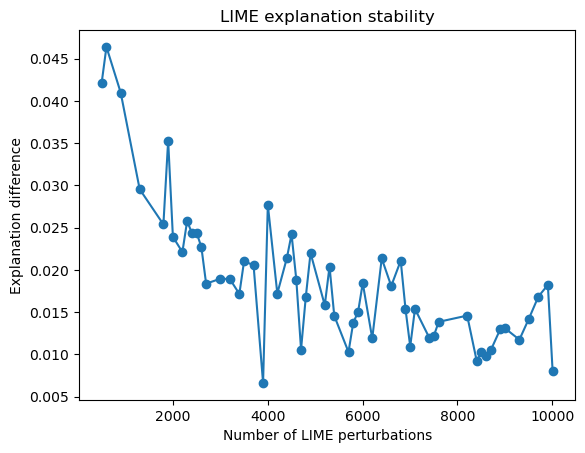

In [21]:
samples = [x[0] for x in stability]
distances = [x[1] for x in stability]

plt.plot(samples, distances, marker="o")

plt.xlabel("Number of LIME perturbations")
plt.ylabel("Explanation difference")
plt.title("LIME explanation stability")

plt.show()

In [22]:
prompt_oncology_specialist =  get_oncology_specialist_prompt(results[5]['prediction_label'], results[5]['feature_importance_map'], 5)
prompt_oncology_specialist

"\n            Role: You are an oncology communication specialist. Your task is to translate \n            Machine Learning outputs (Naive Bayes + LIME) into clear, empathetic, \n            and non-technical language for patients and health professionals.\n            \n            Context: \n            - Dataset: Breast Cancer Wisconsin (Diagnostic).\n            - Input: Class prediction Malignant and top features from LIME.\n            \n            Instructions:\n            1. Identify the 3 most important features provided by LIME: {'fractal dimension error': -0.12578838372712006, 'mean compactness': 0.12088621041853592, 'radius error': 0.12088621041853592, 'symmetry error': 0.12088621041853592, 'mean texture': 0.10705938345501452, 'mean radius': -0.06980760534532074, 'smoothness error': -0.06980760534532074, 'mean smoothness': 0.05107860507321518, 'mean symmetry': 0.05107860507321518, 'texture error': 0.05107860507321518}.\n            2. Explain their clinical meaning simply

In [23]:
prompt_data_analyst = get_data_analyst_prompt(results[5]['prediction_label'], results[5]['feature_importance_map'])
prompt_data_analyst

"\n            Role: You are a data analysis assistant.\n            Task: Explain the output of a machine learning classifier based on the provided feature importance values.\n            \n            Instructions:\n            1. State the model's final prediction: Malignant.\n            2. List the variables that most contributed: {'fractal dimension error': -0.12578838372712006, 'mean compactness': 0.12088621041853592, 'radius error': 0.12088621041853592, 'symmetry error': 0.12088621041853592, 'mean texture': 0.10705938345501452, 'mean radius': -0.06980760534532074, 'smoothness error': -0.06980760534532074, 'mean smoothness': 0.05107860507321518, 'mean symmetry': 0.05107860507321518, 'texture error': 0.05107860507321518}.\n            3. Describe the relationship between these variables in a neutral tone.\n            \n            Avoid technical jargon. Stick to the data provided.\n            Disclaimer: This is an automated data analysis.\n            "

In [24]:
prompt_feature_explainer = get_feature_explainer_prompt(results[5]['prediction_label'], results[5]['feature_importance_map'])
prompt_feature_explainer

"\n            Task: Explain the importance of the features in determining the model's prediction.\n            \n            Instructions:\n            1. Analyze the list: {'fractal dimension error': -0.12578838372712006, 'mean compactness': 0.12088621041853592, 'radius error': 0.12088621041853592, 'symmetry error': 0.12088621041853592, 'mean texture': 0.10705938345501452, 'mean radius': -0.06980760534532074, 'smoothness error': -0.06980760534532074, 'mean smoothness': 0.05107860507321518, 'mean symmetry': 0.05107860507321518, 'texture error': 0.05107860507321518}.\n            2. Translate these mathematical values into a user-friendly explanation.\n            3. Highlight critical features for the classification Malignant.\n            \n            Input Data format:\n            Prediction: Malignant\n            Feature Importance List: {'fractal dimension error': -0.12578838372712006, 'mean compactness': 0.12088621041853592, 'radius error': 0.12088621041853592, 'symmetry error

In [25]:
slm_result_oncology_specialist = query_slm(prompt_oncology_specialist)

In [26]:
slm_result_prompt_data_analyst = query_slm(prompt_data_analyst)

In [27]:
slm_result_feature_explainer = query_slm(prompt_feature_explainer)

In [28]:
save_dict_to_json(slm_result_oncology_specialist, f"../outputs/slm_result_oncology_specialist.json")
save_dict_to_json(slm_result_prompt_data_analyst, f"../outputs/slm_result_prompt_data_analyst.json")
save_dict_to_json(slm_result_feature_explainer, f"../outputs/slm_result_feature_explainer.json")